<a href="https://colab.research.google.com/github/chaturvedulakashyap-source/Simple-Synaptic-Transmission-Model/blob/main/Simple_neuron_synapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

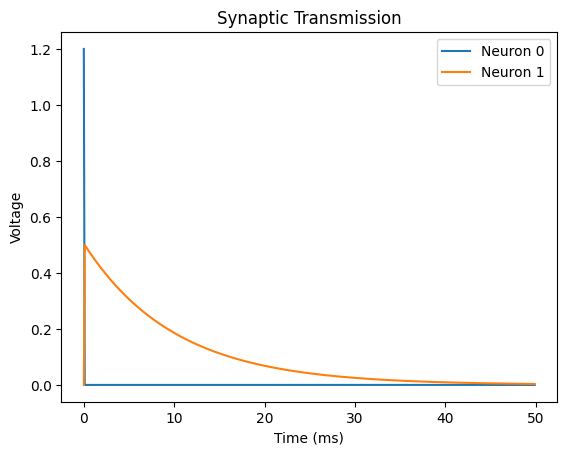

Spike times: [0.]
Spike neurons: <spikemonitor.i: array([0], dtype=int32)>


In [3]:
!pip install brian2 matplotlib

from brian2 import *
import matplotlib.pyplot as plt

start_scope()

# ---------------- NEURON MODEL ----------------
eqs = '''
dv/dt = -v / (10*ms) : 1
'''

# ---------------- TWO NEURONS ----------------
G = NeuronGroup(2, eqs, threshold='v>1', reset='v=0', method='exact')

# Initialize
G.v = [1.2, 0]   # Neuron 0 will spike immediately, neuron 1 starts silent

# ---------------- SYNAPSE ----------------
S = Synapses(G, G, on_pre='v_post += 0.5')
S.connect(i=0, j=1)   # ONLY from neuron 0 → neuron 1

# ---------------- MONITORS ----------------
M = StateMonitor(G, 'v', record=True)
spike_mon = SpikeMonitor(G)

# ---------------- RUN ----------------
run(50*ms)

# ---------------- PLOT ----------------
plt.plot(M.t/ms, M.v[0], label='Neuron 0')
plt.plot(M.t/ms, M.v[1], label='Neuron 1')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage')
plt.legend()
plt.title('Synaptic Transmission')
plt.show()

# ---------------- DEBUG PRINT ----------------
print("Spike times:", spike_mon.t/ms)
print("Spike neurons:", spike_mon.i)